# Phase 3 : Modélisation Prédictive

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve,
                              precision_recall_curve, fbeta_score)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [61]:
df = pd.read_csv("../data/top_features.csv")

# vérification rapide
print(f"Dimensions : {df.shape}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"\nDistribution de la cible :")
print(df["TenYearCHD"].value_counts())
df.head()

Dimensions : (4240, 12)
Valeurs manquantes : 0

Distribution de la cible :
TenYearCHD
0    3596
1     644
Name: count, dtype: int64


,age_sysBP,risk_score,age,sysBP,pulse_pressure,prevalentHyp,diaBP,Tension_Hypertension,Tension_Normale,diabetes,male,TenYearCHD
0,4134.0,0,39,106.0,36.0,0,70.0,0,1,0,1,0
1,5566.0,1,46,121.0,40.0,0,81.0,1,0,0,0,0
2,6120.0,2,48,127.5,47.5,0,80.0,1,0,0,1,0
3,9150.0,6,61,150.0,55.0,1,95.0,1,0,0,0,1
4,5980.0,2,46,130.0,46.0,0,84.0,1,0,0,0,0


## 1. Préparation des données

* Conversion des colonnes booléennes avant le split.

L'encodage des colonnes booléennes est effectué **avant** la séparation train/test pour s'assurer que `x_train` et `x_test` ont des types cohérents dès le départ.

In [62]:
bool_cols = df.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

print(f"Colonnes converties : {bool_cols if bool_cols else 'aucune'}")
print(f"Types après conversion :\n{df.dtypes.value_counts()}")

Colonnes converties : aucune
Types après conversion :
int64      8
float64    4
Name: count, dtype: int64


* Séparation features / cible.

In [63]:
feature = df.drop("TenYearCHD", axis=1)
target  = df["TenYearCHD"]

print(f"Features ({feature.shape[1]}) : {list(feature.columns)}")

Features (11) : ['age_sysBP', 'risk_score', 'age', 'sysBP', 'pulse_pressure', 'prevalentHyp', 'diaBP', 'Tension_Hypertension', 'Tension_Normale', 'diabetes', 'male']


* Séparation des données en ensemble d'entraînement (70 %) et ensemble de test (30 %).

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.3, random_state=42, stratify=target
)

print(f"Taille train : {x_train.shape}  |  test : {x_test.shape}")
print(f"\nDistribution cible (train) :\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribution cible (test)  :\n{y_test.value_counts(normalize=True).round(3)}")

Taille train : (2968, 11)  |  test : (1272, 11)

Distribution cible (train) :
TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64

Distribution cible (test)  :
TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


## 2. Construction des modèles

* Baseline avec un classifieur naïf.

Avant tout modèle appris, on établit une référence (baseline) avec un `DummyClassifier`
qui prédit toujours la classe majoritaire. Tout modèle utile doit dépasser ce niveau.

In [65]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)
y_pred_dummy = dummy.predict(x_test)

print("Baseline (DummyClassifier - most_frequent) :")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_dummy):.3f}  <- trompeur a cause du desequilibre")
print(f"  Recall   : {recall_score(y_test, y_pred_dummy, zero_division=0):.3f}  <- detecle 0 malade")
print(f"  ROC-AUC  : {roc_auc_score(y_test, dummy.predict_proba(x_test)[:, 1]):.3f}")
print("=> Tout modele utile doit avoir Recall > 0 et AUC > 0.5")

Baseline (DummyClassifier - most_frequent) :
  Accuracy : 0.848  <- trompeur a cause du desequilibre
  Recall   : 0.000  <- detecle 0 malade
  ROC-AUC  : 0.500
=> Tout modele utile doit avoir Recall > 0 et AUC > 0.5


* Définition des pipelines de modélisation.

Chaque modèle est encapsulé dans un `Pipeline` scikit-learn qui intègre la normalisation.
Cette approche garantit qu'il n'y a aucune fuite d'information : le scaler est fitté
uniquement sur les données d'entraînement à chaque fold de validation croisée.

In [66]:
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

print(f"{len(models)} pipelines configurés : {list(models.keys())}")

4 pipelines configurés : ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'HistGradientBoosting']


* Entraînement et évaluation initiale sur le jeu de test.

In [67]:
results = []

for name, model in models.items():
    print("=" * 50)
    print(f"Entraînement : {name}")

    model.fit(x_train, y_train)

    y_pred  = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    # on ajoute Fbeta(2) qui donne plus de poids au recall — important en médical
    results.append({
        "Modele"    : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred), 3),
        "Precision" : round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall"    : round(recall_score(y_test, y_pred), 3),
        "F1-Score"  : round(f1_score(y_test, y_pred), 3),
        "Fbeta(2)"  : round(fbeta_score(y_test, y_pred, beta=2), 3),
        "ROC-AUC"   : round(roc_auc_score(y_test, y_proba), 3),
    })

    print(classification_report(y_test, y_pred, target_names=["Non CHD", "CHD"]))

results_df = pd.DataFrame(results).set_index("Modele")
print("\nComparaison des modèles :")
print(results_df.sort_values("ROC-AUC", ascending=False))

Entraînement : LogisticRegression


              precision    recall  f1-score   support

     Non CHD       0.91      0.67      0.77      1079
         CHD       0.26      0.63      0.36       193

    accuracy                           0.67      1272
   macro avg       0.58      0.65      0.57      1272
weighted avg       0.81      0.67      0.71      1272

Entraînement : RandomForest
              precision    recall  f1-score   support

     Non CHD       0.89      0.77      0.82      1079
         CHD       0.26      0.47      0.34       193

    accuracy                           0.72      1272
   macro avg       0.58      0.62      0.58      1272
weighted avg       0.79      0.72      0.75      1272

Entraînement : GradientBoosting
              precision    recall  f1-score   support

     Non CHD       0.85      0.98      0.91      1079
         CHD       0.37      0.07      0.12       193

    accuracy                           0.84      1272
   macro avg       0.61      0.53      0.52      1272
weighted avg  

> **Note :** On a ajouté la métrique `Fbeta(2)` qui donne deux fois plus de poids au Recall qu'à la Précision. C'est plus pertinent ici car manquer un malade (faux négatif) est plus grave qu'une fausse alarme.

* Visualisation des métriques pour tous les modèles.

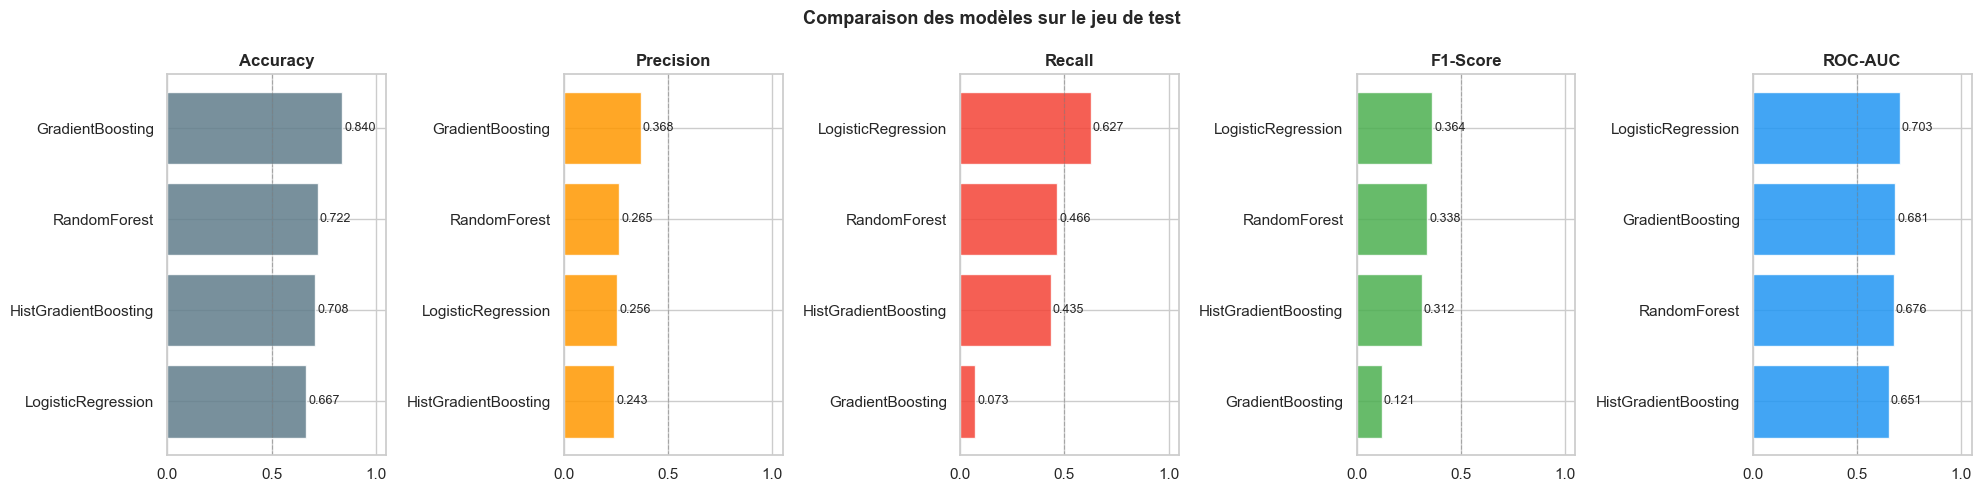

In [68]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
df_plot = results_df[metrics_to_plot].reset_index()

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
colors = ["#607D8B", "#FF9800", "#F44336", "#4CAF50", "#2196F3"]

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    sorted_df = df_plot.sort_values(metric, ascending=True)
    axes[i].barh(sorted_df["Modele"], sorted_df[metric], color=color, alpha=0.85,
                 edgecolor="white")
    axes[i].set_title(metric, fontweight="bold")
    axes[i].set_xlim(0, 1.05)
    axes[i].axvline(0.5, color="gray", linestyle="--", lw=0.8, alpha=0.5)
    for j, v in enumerate(sorted_df[metric]):
        axes[i].text(v + 0.01, j, f"{v:.3f}", va="center", fontsize=9)

plt.suptitle("Comparaison des modèles sur le jeu de test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Validation croisée et sélection du meilleur modèle

* Validation croisée stratifiée (5 folds) sur le jeu d'entraînement.

La validation croisée est effectuée sur `x_train` brut. Chaque pipeline applique
sa propre normalisation à l'intérieur de chaque fold, ce qui garantit l'absence de
fuite d'information.

In [69]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, pipe in models.items():
    auc_scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc',  n_jobs=-1)
    rec_scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='recall',   n_jobs=-1)
    f1_scores  = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='f1',       n_jobs=-1)

    cv_results.append({
        "Model"       : name,
        "AUC moyen"   : round(auc_scores.mean(), 4),
        "AUC std"     : round(auc_scores.std(),  4),
        "Recall moyen": round(rec_scores.mean(), 4),
        "Recall std"  : round(rec_scores.std(),  4),
        "F1 moyen"    : round(f1_scores.mean(),  4),
        "F1 std"      : round(f1_scores.std(),   4),
    })
    print(f"{name:25s} | AUC={auc_scores.mean():.4f} +/- {auc_scores.std():.4f}"
          f" | Recall={rec_scores.mean():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("AUC moyen", ascending=False)
print("\nRésultats validation croisée :")
print(cv_df.to_string(index=False))

LogisticRegression        | AUC=0.7246 +/- 0.0180 | Recall=0.6674
RandomForest              | AUC=0.7075 +/- 0.0113 | Recall=0.4745
GradientBoosting          | AUC=0.6966 +/- 0.0240 | Recall=0.0932
HistGradientBoosting      | AUC=0.6843 +/- 0.0189 | Recall=0.4790

Résultats validation croisée :
               Model  AUC moyen  AUC std  Recall moyen  Recall std  F1 moyen  F1 std
  LogisticRegression     0.7246   0.0180        0.6674      0.0211    0.3843  0.0288
        RandomForest     0.7075   0.0113        0.4745      0.0384    0.3614  0.0328
    GradientBoosting     0.6966   0.0240        0.0932      0.0168    0.1511  0.0251
HistGradientBoosting     0.6843   0.0189        0.4790      0.0276    0.3422  0.0191


* Visualisation de la comparaison des modèles en validation croisée.

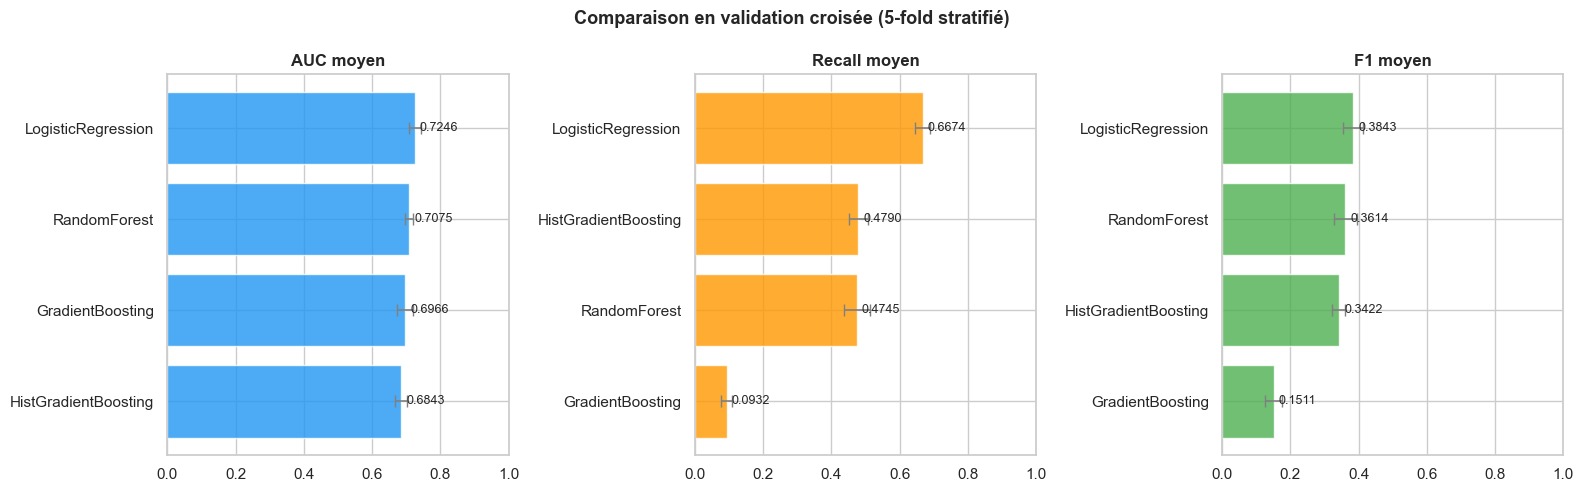

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["AUC moyen", "Recall moyen", "F1 moyen"]
colors  = ["#2196F3", "#FF9800", "#4CAF50"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    # on trie par ordre croissant pour que le meilleur soit en haut
    cv_df_sorted = cv_df.sort_values(metric, ascending=True)

    # on ajoute les barres d'erreur (ecart-type) — important pour voir la stabilite
    std_col = {"AUC moyen": "AUC std", "Recall moyen": "Recall std", "F1 moyen": "F1 std"}[metric]
    axes[i].barh(cv_df_sorted["Model"], cv_df_sorted[metric],
                 xerr=cv_df_sorted[std_col],
                 color=color, alpha=0.8, edgecolor="white",
                 error_kw=dict(ecolor="gray", capsize=4, lw=1.2))
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlim(0, 1)
    for j, v in enumerate(cv_df_sorted[metric]):
        axes[i].text(v + 0.015, j, f"{v:.4f}", va='center', fontsize=9)

plt.suptitle("Comparaison en validation croisée (5-fold stratifié)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Amélioration :** On affiche maintenant les barres d'erreur (écart-type) sur chaque métrique. Un modèle avec une forte variance entre les folds est moins fiable, même s'il a un bon score moyen.

## 4. Optimisation par recherche sur grille

* Sélection du meilleur modèle et optimisation des hyperparamètres.

Le modèle retenant le meilleur AUC moyen en validation croisée est sélectionné
pour l'optimisation. Le `GridSearchCV` est exécuté sur `x_train` brut —
la normalisation est intégrée dans le pipeline.

In [71]:
best_model_name = cv_df.iloc[0]["Model"]
print(f"Meilleur modèle en CV : {best_model_name}")
print(f"AUC moyen : {cv_df.iloc[0]['AUC moyen']:.4f}")

param_grids = {
    "LogisticRegression": {
        "model__C"      : [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l1", "l2"],
        "model__solver" : ["liblinear"],
    },
    "RandomForest": {
        "model__n_estimators"    : [200, 300],
        "model__max_depth"       : [6, 8, 10],
        "model__min_samples_leaf": [3, 5, 8],
    },
    "GradientBoosting": {
        "model__n_estimators" : [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth"    : [3, 4, 5],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_iter"     : [200, 300],
        "model__max_depth"    : [4, 5, 6],
    }
}

grid_search = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True   # pour vérifier l'overfitting après
)
grid_search.fit(x_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur AUC CV      : {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_

Meilleur modèle en CV : LogisticRegression
AUC moyen : 0.7246
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Meilleurs paramètres : {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Meilleur AUC CV      : 0.7264


* Vérification de l'overfitting après GridSearch.

In [72]:
# on compare le score train vs validation pour détecter un éventuel sur-apprentissage
cv_res = pd.DataFrame(grid_search.cv_results_)
best_idx = grid_search.best_index_

train_auc = cv_res.loc[best_idx, "mean_train_score"]
val_auc   = cv_res.loc[best_idx, "mean_test_score"]
gap       = train_auc - val_auc

print(f"AUC moyen train      : {train_auc:.4f}")
print(f"AUC moyen validation : {val_auc:.4f}")
print(f"Gap train-val        : {gap:.4f}")

if gap < 0.05:
    print("=> Pas de sur-apprentissage détecté")
elif gap < 0.10:
    print("=> Léger sur-apprentissage, acceptable")
else:
    print("=> Sur-apprentissage significatif, attention")

AUC moyen train      : 0.7298
AUC moyen validation : 0.7264
Gap train-val        : 0.0034
=> Pas de sur-apprentissage détecté


## 5. Évaluation finale du modèle optimisé

* Optimisation du seuil de décision.

Dans un contexte de dépistage médical, minimiser les faux négatifs (patients malades
classés comme sains) est prioritaire. On cherche donc le seuil qui maximise le Recall
tout en gardant un Fbeta(2) raisonnable.

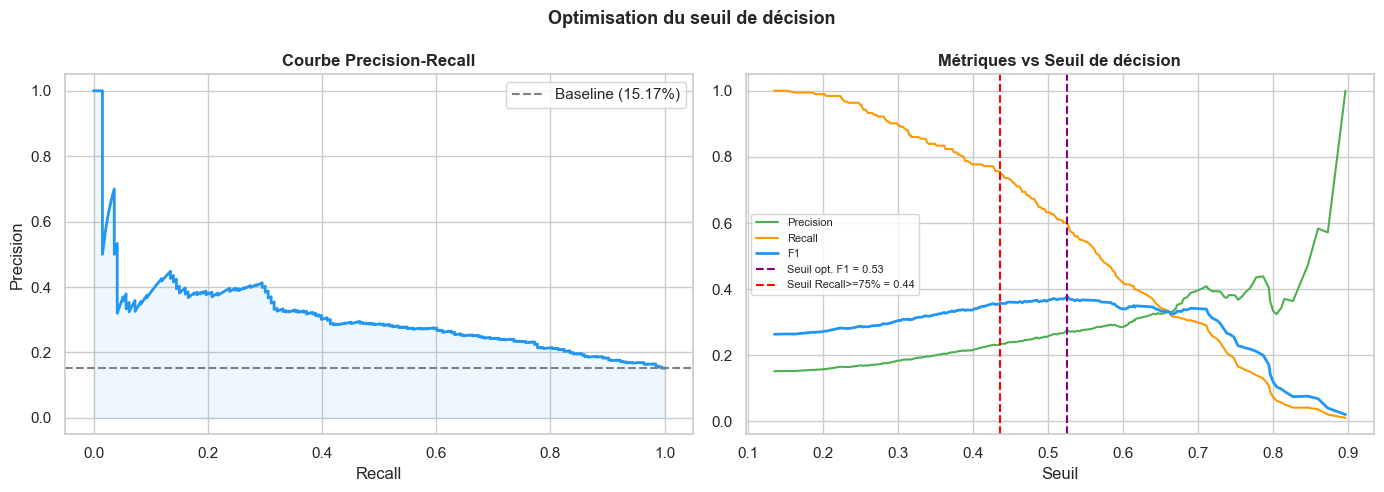

Seuil optimal F1          : 0.525
Seuil pour Recall >= 75 % : 0.436


In [73]:
y_proba_test = best_model.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)
f1_scores_thr = 2 * precisions * recalls / (precisions + recalls + 1e-9)

best_thr_f1 = thresholds[np.argmax(f1_scores_thr[:-1])]

recall_75_idx = np.where(recalls >= 0.75)[0]
best_thr_recall = thresholds[recall_75_idx[-1]] if len(recall_75_idx) > 0 else 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='#2196F3', lw=2)
axes[0].fill_between(recalls, precisions, alpha=0.07, color='#2196F3')
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test.mean():.2%})')
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Courbe Precision-Recall", fontweight="bold")
axes[0].legend()

thr_range = thresholds[::5]
axes[1].plot(thr_range, precisions[::5],    label='Precision', color='#4CAF50')
axes[1].plot(thr_range, recalls[::5],       label='Recall',    color='#FF9800')
axes[1].plot(thr_range, f1_scores_thr[::5], label='F1',        color='#2196F3', lw=2)
axes[1].axvline(best_thr_f1,     color='purple', linestyle='--',
                label=f'Seuil opt. F1 = {best_thr_f1:.2f}')
axes[1].axvline(best_thr_recall, color='red',    linestyle='--',
                label=f'Seuil Recall>=75% = {best_thr_recall:.2f}')
axes[1].set_xlabel("Seuil")
axes[1].set_title("Métriques vs Seuil de décision", fontweight="bold")
axes[1].legend(fontsize=8)

plt.suptitle("Optimisation du seuil de décision", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Seuil optimal F1          : {best_thr_f1:.3f}")
print(f"Seuil pour Recall >= 75 % : {best_thr_recall:.3f}")

* Comparaison des performances selon le seuil retenu.

In [74]:
seuils = [
    ("Seuil 0.50 (defaut)",                        0.5),
    (f"Seuil {best_thr_f1:.2f} (opt. F1)",         best_thr_f1),
    (f"Seuil {best_thr_recall:.2f} (Recall>=75%)", best_thr_recall),
]

rows = []
for label, thr in seuils:
    y_pred_thr = (y_proba_test >= thr).astype(int)
    rows.append({
        "Seuil"    : label,
        "Recall"   : round(recall_score(y_test, y_pred_thr), 4),
        "Precision": round(precision_score(y_test, y_pred_thr, zero_division=0), 4),
        "F1"       : round(f1_score(y_test, y_pred_thr), 4),
        "Fbeta(2)" : round(fbeta_score(y_test, y_pred_thr, beta=2), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba_test), 4),
    })

seuil_df = pd.DataFrame(rows).set_index("Seuil")
print("Comparaison des seuils :")
print(seuil_df.to_string())

Comparaison des seuils :
                          Recall  Precision      F1  Fbeta(2)  ROC-AUC
Seuil                                                                 
Seuil 0.50 (defaut)       0.6321     0.2579  0.3664    0.4900   0.7033
Seuil 0.53 (opt. F1)      0.6010     0.2749  0.3772    0.4858   0.7033
Seuil 0.44 (Recall>=75%)  0.7513     0.2342  0.3571    0.5212   0.7033


* Matrice de confusion et courbe ROC (seuil orienté recall).

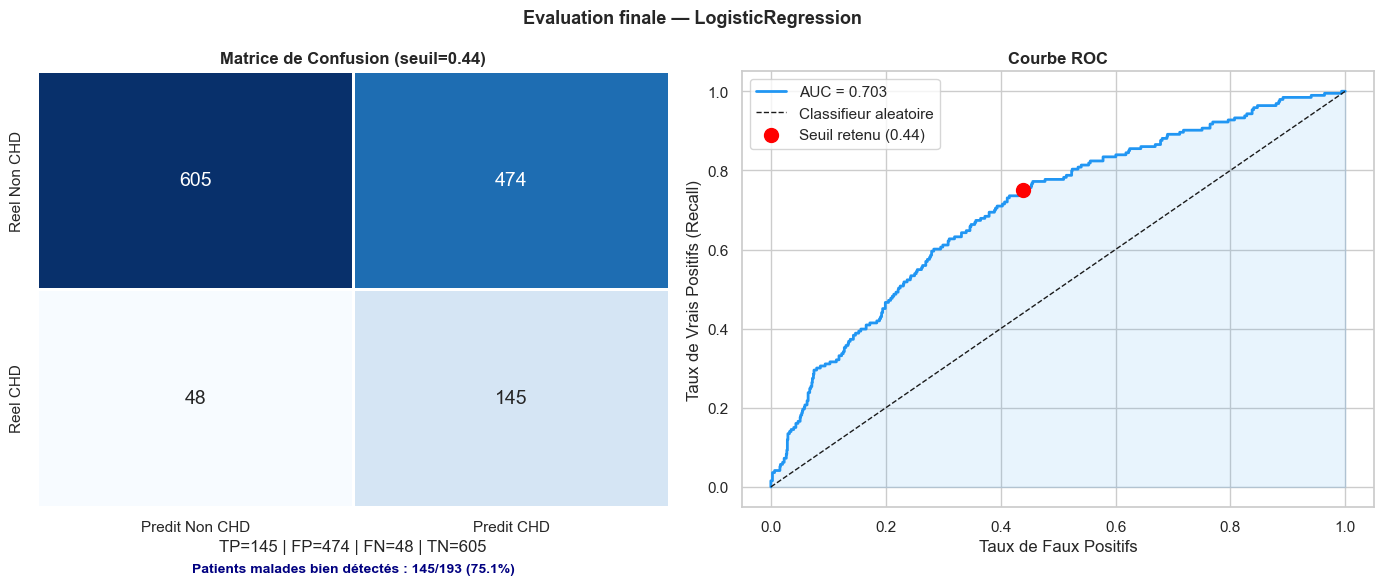


Classification Report :
              precision    recall  f1-score   support

     Non CHD       0.93      0.56      0.70      1079
         CHD       0.23      0.75      0.36       193

    accuracy                           0.59      1272
   macro avg       0.58      0.66      0.53      1272
weighted avg       0.82      0.59      0.65      1272



In [75]:
y_pred_final = (y_proba_test >= best_thr_recall).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predit Non CHD', 'Predit CHD'],
            yticklabels=['Reel Non CHD', 'Reel CHD'],
            linewidths=1, annot_kws={"size": 14}, cbar=False)
axes[0].set_title(f"Matrice de Confusion (seuil={best_thr_recall:.2f})", fontweight='bold')
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"TP={tp} | FP={fp} | FN={fn} | TN={tn}")
# note médicale
axes[0].text(0.5, -0.15,
             f"Patients malades bien détectés : {tp}/{tp+fn} ({tp/(tp+fn):.1%})",
             ha="center", transform=axes[0].transAxes,
             fontsize=10, color="navy", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Classifieur aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')

# on marque le point correspondant au seuil retenu sur la courbe ROC
fpr_pt = fp / (fp + tn)
tpr_pt = tp / (tp + fn)
axes[1].scatter(fpr_pt, tpr_pt, color='red', s=100, zorder=5,
                label=f'Seuil retenu ({best_thr_recall:.2f})')

axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs (Recall)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()

plt.suptitle(f"Evaluation finale — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report :")
print(classification_report(y_test, y_pred_final, target_names=['Non CHD', 'CHD']))

> **Amélioration :** On affiche maintenant le point correspondant au seuil retenu directement sur la courbe ROC, et on ajoute une note sur le nombre de malades bien détectés.

* Importance des features du modèle optimisé.

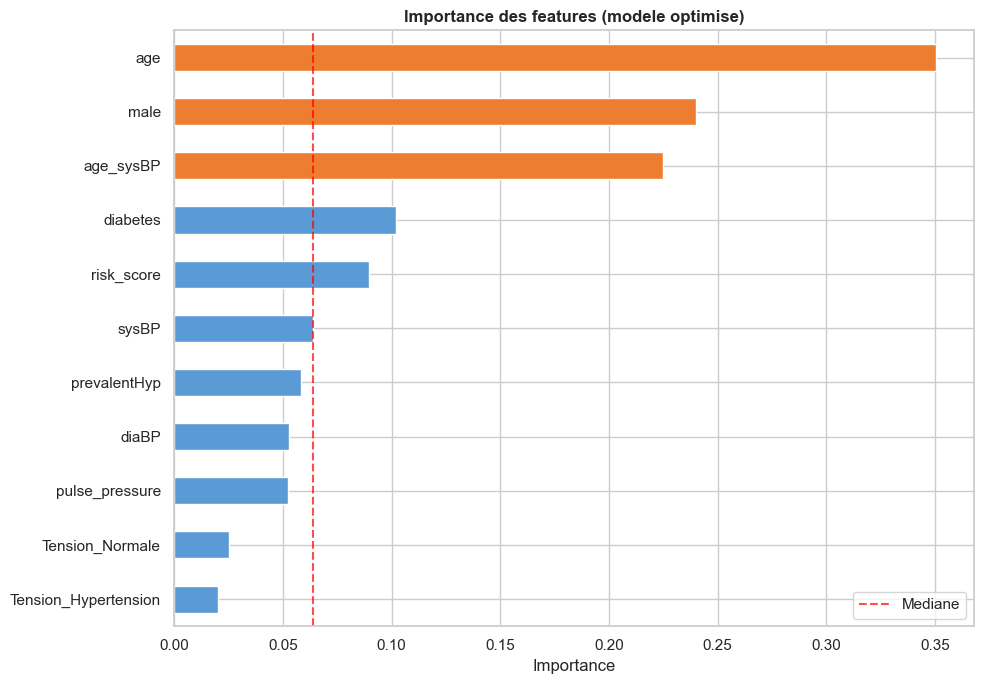

Top 5 features :
age           0.350429
male          0.239994
age_sysBP     0.224715
diabetes      0.101938
risk_score    0.089758
dtype: float64


In [76]:
model_obj = best_model.named_steps['model']

if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    feat_names  = feature.columns
elif hasattr(model_obj, 'coef_'):
    importances = np.abs(model_obj.coef_[0])
    feat_names  = feature.columns
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        best_model, x_test, y_test,
        n_repeats=20, scoring='roc_auc',
        random_state=42, n_jobs=-1
    )
    importances = perm.importances_mean
    feat_names  = feature.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)

# les 3 plus importantes en orange, le reste en bleu
n = len(feat_imp)
bar_colors = ['#ED7D31' if i >= n - 3 else '#5B9BD5' for i in range(n)]

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor="white")
ax.axvline(feat_imp.median(), color='red', linestyle='--', alpha=0.7, label='Mediane')
ax.set_title("Importance des features (modele optimise)", fontweight='bold')
ax.set_xlabel("Importance")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features :")
print(feat_imp.sort_values(ascending=False).head(5))

* Sauvegarde du modèle final.

Le pipeline complet est sauvegardé. Il contient la normalisation et le modèle. Il suffit de charger ce fichier pour effectuer des prédictions sur de nouvelles données, sans refaire la normalisation.

In [ ]:
os.makedirs("../outputs", exist_ok=True)
joblib.dump(best_model, "../outputs/best_model.pkl")
joblib.dump(scaler, "../outputs/scaler.pkl")
print(f"Modele sauvegardé : ../outputs/best_model.pkl")

# vérification rapide du rechargement
model_recharge = joblib.load("../outputs/best_model.pkl")
test_proba = model_recharge.predict_proba(x_test[:3])[:, 1]
print(f"Vérification OK — probabilités : {test_proba.round(3)}")

Modele sauvegardé : ../outputs/best_model.pkl
Vérification OK — probabilités : [0.405 0.629 0.361]


## 6. Résumé des résultats

In [79]:
print("=" * 55)
print("     RÉSUMÉ FINAL DE LA MODÉLISATION")
print("=" * 55)
print(f"  Modèle retenu       : {best_model_name}")
print(f"  Meilleurs params    : {grid_search.best_params_}")
print(f"  AUC moyen (CV)      : {grid_search.best_score_:.4f}")
print(f"  AUC (test)          : {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"  Seuil retenu        : {best_thr_recall:.3f}  (Recall >= 75 %)")
print()
print(f"  Recall  (test)      : {recall_score(y_test, y_pred_final):.4f}")
print(f"  Precision (test)    : {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  F1-Score (test)     : {f1_score(y_test, y_pred_final):.4f}")
print(f"  Fbeta(2) (test)     : {fbeta_score(y_test, y_pred_final, beta=2):.4f}")
print()
print("  Top 5 features :")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"    - {feat:20s} : {val:.4f}")
print("=" * 55)

     RÉSUMÉ FINAL DE LA MODÉLISATION
  Modèle retenu       : LogisticRegression
  Meilleurs params    : {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
  AUC moyen (CV)      : 0.7264
  AUC (test)          : 0.7033
  Seuil retenu        : 0.436  (Recall >= 75 %)

  Recall  (test)      : 0.7513
  Precision (test)    : 0.2342
  F1-Score (test)     : 0.3571
  Fbeta(2) (test)     : 0.5212

  Top 5 features :
    - age                  : 0.3504
    - male                 : 0.2400
    - age_sysBP            : 0.2247
    - diabetes             : 0.1019
    - risk_score           : 0.0898
